In [168]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [169]:
df = pd.read_csv('data\customer_segmentation.csv')
df

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\namde\AppData\Local\Temp\ipykernel_5356\629626553.py:1: SyntaxWarning: invalid escape sequence '\c'
  df = pd.read_csv('data\customer_segmentation.csv')


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [170]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [171]:
df.nunique()

ID                     2240
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             663
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         558
MntFishProducts         182
MntSweetProducts        177
MntGoldProds            213
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

In [172]:
# Deleting Z_CostContact and Z_Revenue as they dont make any variation in the data
df.drop(columns=['Z_CostContact','Z_Revenue'],inplace=True)

In [173]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [174]:
df.duplicated().sum()

np.int64(0)

In [175]:
# to check which column has null values
for i in df.columns:
    var = df[i].isna().sum()
    if var > 0:
        print(f'Column "{i}" has {var} missing values')

Column "Income" has 24 missing values


In [176]:
# Dropping the rows as it wont affect the data much
df.dropna(inplace=True)

In [177]:
df.shape

(2216, 27)

In [178]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2216.0,5588.353339,3249.376275,0.0,2814.75,5458.5,8421.75,11191.0
Year_Birth,2216.0,1968.820397,11.985554,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2216.0,0.441787,0.536896,0.0,0.00,0.0,1.00,2.0
Teenhome,2216.0,0.505415,0.544181,0.0,0.00,0.0,1.00,2.0
Recency,2216.0,49.012635,28.948352,0.0,24.00,49.0,74.00,99.0
MntWines,2216.0,305.091606,337.327920,0.0,24.00,174.5,505.00,1493.0
MntFruits,2216.0,26.356047,39.793917,0.0,2.00,8.0,33.00,199.0
MntMeatProducts,2216.0,166.995939,224.283273,0.0,16.00,68.0,232.25,1725.0
MntFishProducts,2216.0,37.637635,54.752082,0.0,3.00,12.0,50.00,259.0


<Axes: ylabel='Income'>

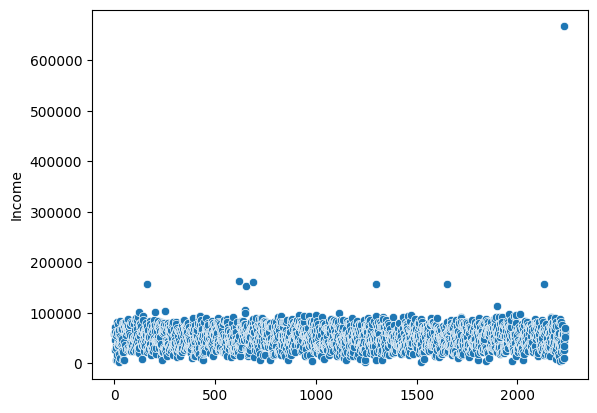

In [179]:
sns.scatterplot(df['Income'])

In [180]:
for i in ['Education','Marital_Status','Kidhome','Teenhome']:
    print(df[i].value_counts())

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64
Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64
Kidhome
0    1283
1     887
2      46
Name: count, dtype: int64
Teenhome
0    1147
1    1018
2      51
Name: count, dtype: int64


<Axes: xlabel='Kidhome', ylabel='count'>

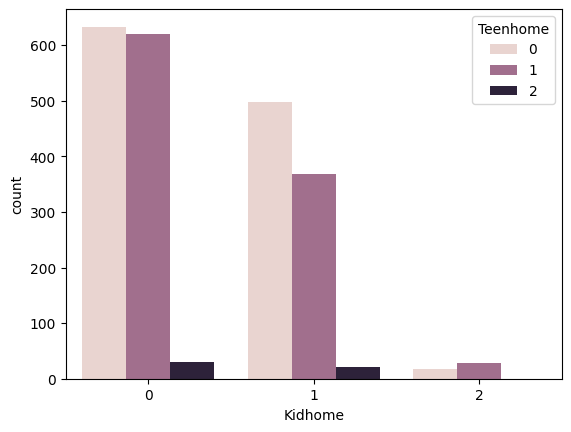

In [181]:
sns.countplot(data=df, x = 'Kidhome',hue='Teenhome')

In [182]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

In [183]:
df['Dt_Customer'].info()

<class 'pandas.Series'>
Index: 2216 entries, 0 to 2239
Series name: Dt_Customer
Non-Null Count  Dtype         
--------------  -----         
2216 non-null   datetime64[us]
dtypes: datetime64[us](1)
memory usage: 34.6 KB


In [184]:
df['Age'] = 2026 - df['Year_Birth']
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,4,7,0,0,0,0,0,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,5,0,0,0,0,0,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,10,4,0,0,0,0,0,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,4,6,0,0,0,0,0,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,6,5,0,0,0,0,0,0,0,45


In [185]:
df['Age'].describe()

count    2216.000000
mean       57.179603
std        11.985554
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max       133.000000
Name: Age, dtype: float64

<Axes: ylabel='Age'>

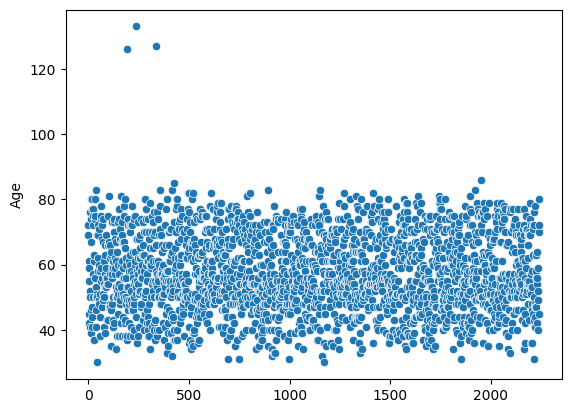

In [186]:
sns.scatterplot(df['Age'])

# Feature Engineering

In [187]:
df = df[df['Age'] <= 100]
df.shape

(2213, 28)

<Axes: ylabel='Age'>

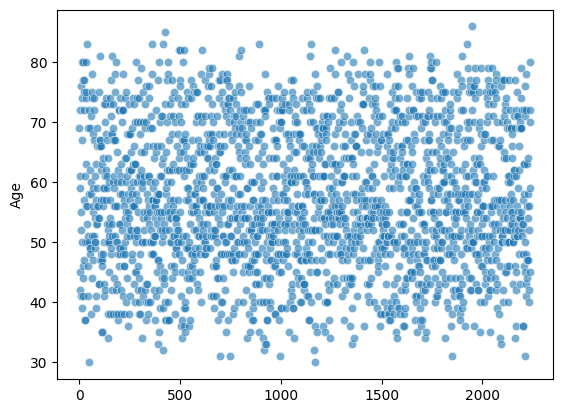

In [225]:
sns.scatterplot(df['Age'], alpha=0.6)

In [188]:
df['Total_children'] = df['Teenhome'] + df['Kidhome']
df['Total_children']

0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: Total_children, Length: 2213, dtype: int64

In [189]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Total_children'],
      dtype='str')

In [190]:
temp = ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']
df['Total_spending'] = df[temp].sum(axis=1)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Total_children,Total_spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,1,69,0,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,0,72,2,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,0,61,0,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,0,42,1,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,0,45,1,422


In [191]:
df[['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']]

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,635,88,546,172,88,88,3,8,10,4,7
1,11,1,6,2,1,6,2,1,1,2,5
2,426,49,127,111,21,42,1,8,2,10,4
3,11,4,20,10,3,5,2,2,0,4,6
4,173,43,118,46,27,15,5,5,3,6,5
...,...,...,...,...,...,...,...,...,...,...,...
2235,709,43,182,42,118,247,2,9,3,4,5
2236,406,0,30,0,0,8,7,8,2,5,7
2237,908,48,217,32,12,24,1,2,3,13,6
2238,428,30,214,80,30,61,2,6,5,10,3


In [192]:
# NOTE: " Number of puchase " & " Amount spent " are different

In [193]:
temp = ['NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
df['Total_num_purchase'] = df[temp].sum(axis=1)
df['Total_num_purchase']

0       32
1       11
2       25
3       14
4       24
        ..
2235    23
2236    29
2237    25
2238    26
2239    18
Name: Total_num_purchase, Length: 2213, dtype: int64

In [194]:
temp = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2']
df['Total_campaign_accepted'] = df[temp].sum(axis=1)
df['Total_campaign_accepted']

# Customers who accepted more campaigns = highly engaged customers = target them first for future campaigns

0       0
1       0
2       0
3       0
4       0
       ..
2235    0
2236    1
2237    1
2238    0
2239    0
Name: Total_campaign_accepted, Length: 2213, dtype: int64

In [195]:
df['Total_campaign_accepted'].value_counts()

Total_campaign_accepted
0    1755
1     322
2      81
3      44
4      11
Name: count, dtype: int64

In [196]:
df['Income'].describe()

count      2213.000000
mean      52236.581563
std       25178.603047
min        1730.000000
25%       35246.000000
50%       51373.000000
75%       68487.000000
max      666666.000000
Name: Income, dtype: float64

In [197]:
out = df[df['Income'] >= 600000]
out

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Total_children,Total_spending,Total_num_purchase,Total_campaign_accepted
2233,9432,1977,Graduation,Together,666666.0,1,0,2013-06-02,23,9,...,0,0,0,0,0,49,1,62,17,0


In [198]:
# Dropped the outlier
df = df.drop(df[df['ID'] == 9432].index)

# EDA

Text(0.5, 1.0, 'Age distribution')

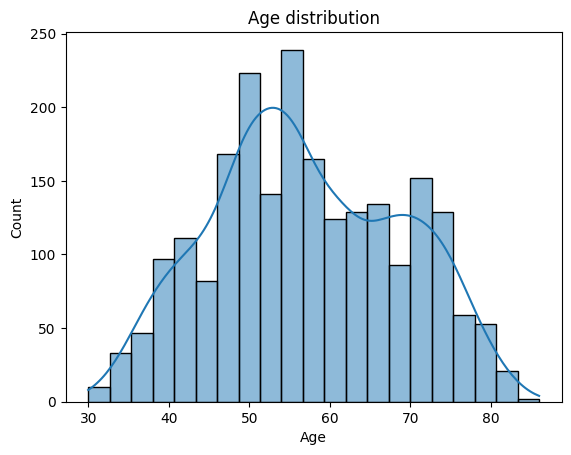

In [199]:
sns.histplot(df['Age'], kde=True)
plt.title('Age distribution')

In [200]:
df[df['Age'] > 100]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Total_children,Total_spending,Total_num_purchase,Total_campaign_accepted


<Axes: xlabel='Income', ylabel='Count'>

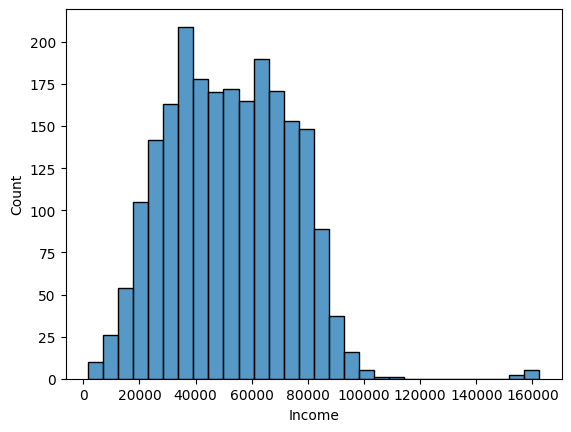

In [201]:
sns.histplot(df['Income'], bins=30)

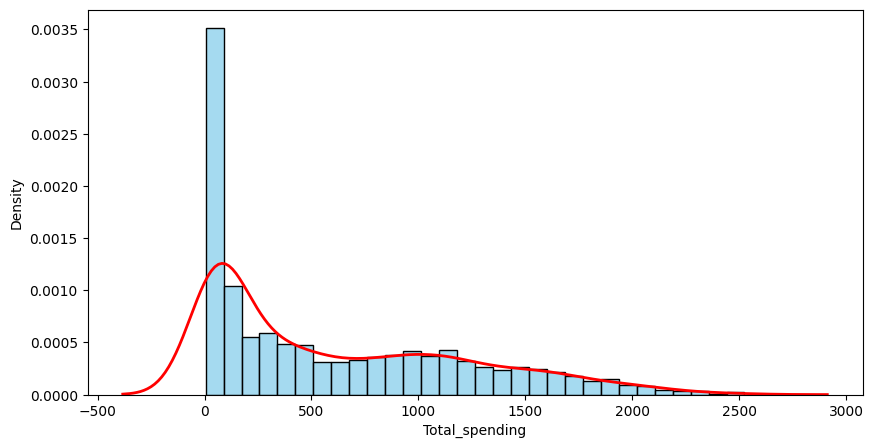

In [202]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['Total_spending'], bins=30, color='skyblue', stat='density', ax=ax)
sns.kdeplot(df['Total_spending'], color='red', linewidth=2, ax=ax)
plt.show()

<Axes: xlabel='Education', ylabel='Income'>

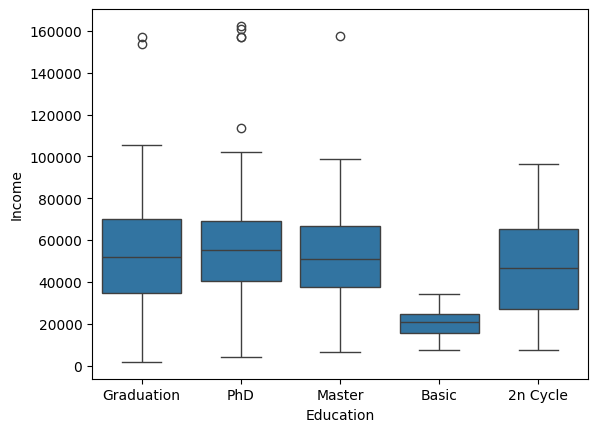

In [203]:
sns.boxplot(data=df, x = 'Education', y='Income')

<Axes: xlabel='Marital_Status', ylabel='Income'>

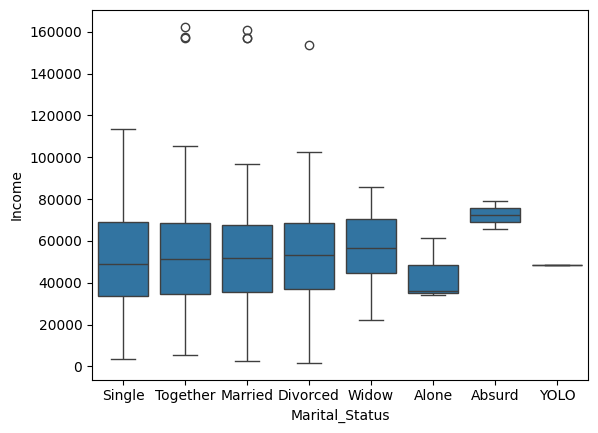

In [204]:
sns.boxplot(data=df, y= "Income", x='Marital_Status')

<Axes: xlabel='Marital_Status', ylabel='Total_spending'>

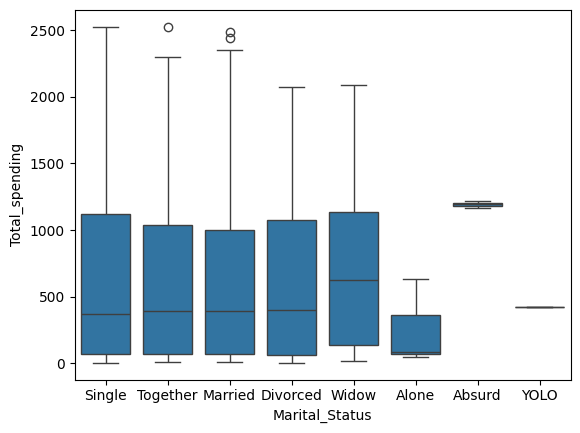

In [205]:
sns.boxplot(data=df, y= "Total_spending", x='Marital_Status')

<Axes: xlabel='Income', ylabel='Total_spending'>

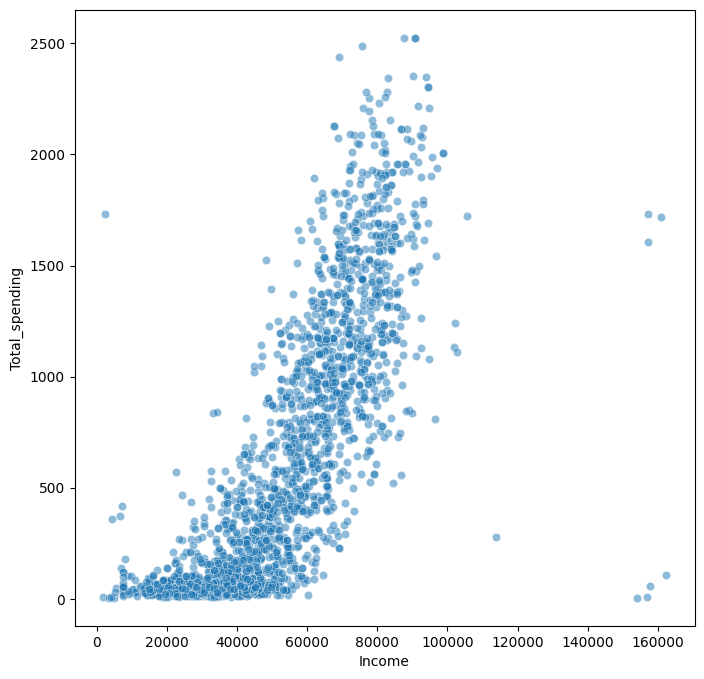

In [206]:
plt.figure(figsize=(8,8))
sns.scatterplot(data = df, x='Income', y='Total_spending', alpha=0.5)

In [207]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Total_children',
       'Total_spending', 'Total_num_purchase', 'Total_campaign_accepted'],
      dtype='str')

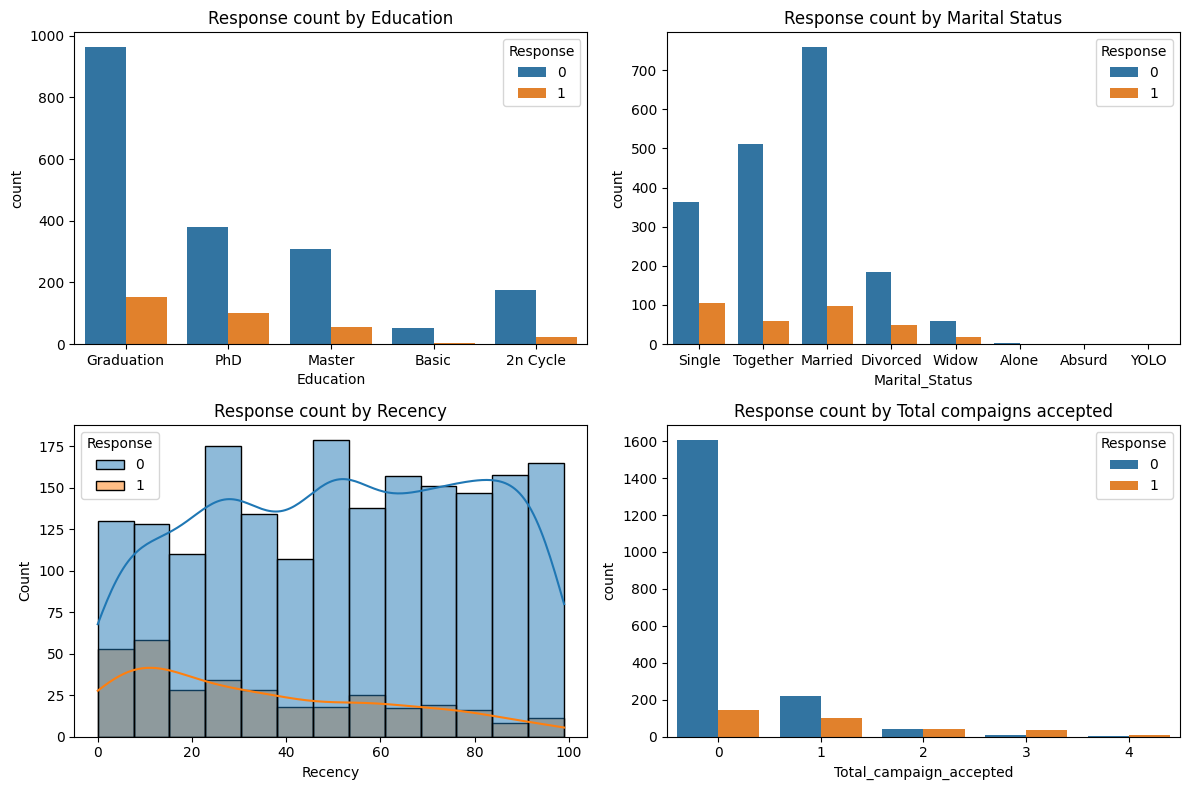

In [208]:
plt.figure(figsize=(12, 8))

plt.subplot(221)
sns.countplot(data=df, x='Education', hue='Response')
plt.title('Response count by Education')

plt.subplot(222)
sns.countplot(data=df, x='Marital_Status', hue='Response')
plt.title('Response count by Marital Status')

plt.subplot(223)
sns.histplot(data=df, x='Recency', hue='Response', kde=True)
plt.title('Response count by Recency')

plt.subplot(224)
sns.countplot(data=df, x='Total_campaign_accepted', hue='Response')
plt.title('Response count by Total compaigns accepted')

plt.tight_layout()
plt.show()

In [209]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Total_children',
       'Total_spending', 'Total_num_purchase', 'Total_campaign_accepted'],
      dtype='str')

In [210]:
corr = df[['Income','Total_spending','Total_num_purchase','Recency','Total_campaign_accepted']].corr()

<Axes: >

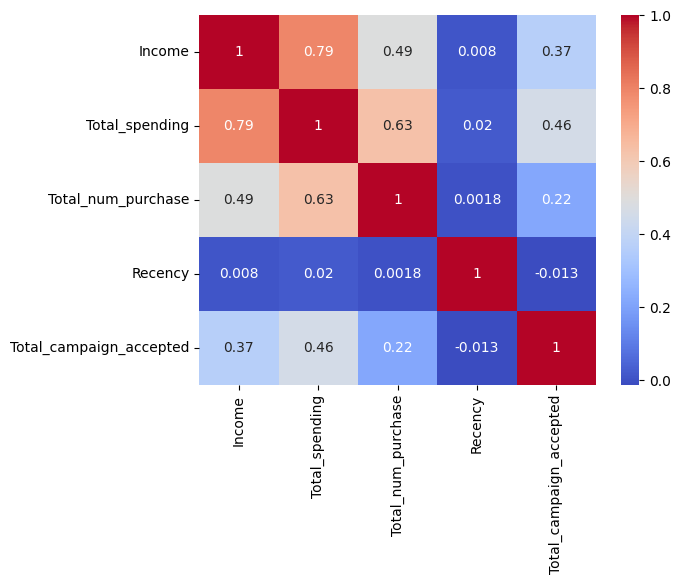

In [211]:
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [212]:
pivot_tab = df.pivot_table(values='Income',index='Education',columns='Marital_Status', aggfunc='mean')

<Axes: xlabel='Marital_Status', ylabel='Education'>

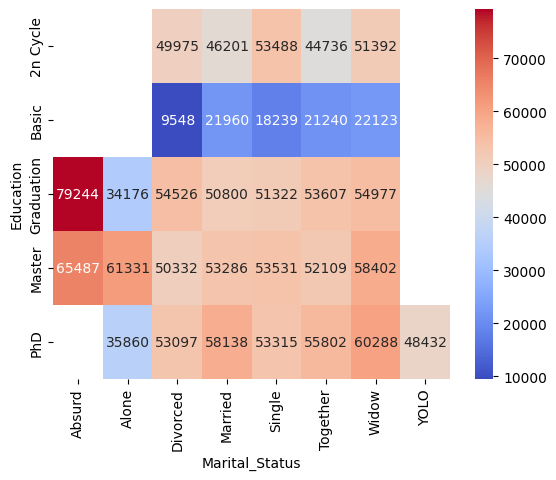

In [213]:
sns.heatmap(pivot_tab, cmap='coolwarm', annot=True, fmt='.0f')

In [214]:
grp1 = df.groupby('Education')['Total_spending'].mean().sort_values(ascending=False)
grp1

Education
PhD           674.283333
Graduation    622.188341
Master        609.767123
2n Cycle      499.489899
Basic          81.796296
Name: Total_spending, dtype: float64

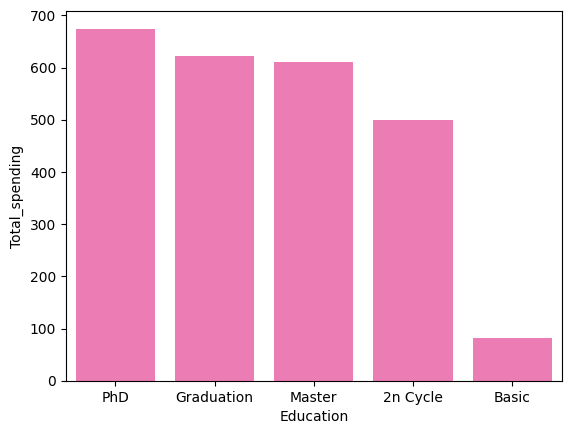

In [215]:
sns.barplot(grp1, color='hotpink')
plt.show()

In [216]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Total_children',
       'Total_spending', 'Total_num_purchase', 'Total_campaign_accepted'],
      dtype='str')

In [217]:
df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']]

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
0,0,0,0,0,0,1
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
2235,0,0,0,0,0,0
2236,1,0,0,0,0,0
2237,0,0,0,1,0,0
2238,0,0,0,0,0,0


In [218]:
df['AcceptedAny'] = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']].sum(axis=1)
df['AcceptedAny']

0       1
1       0
2       0
3       0
4       0
       ..
2235    0
2236    1
2237    1
2238    0
2239    1
Name: AcceptedAny, Length: 2212, dtype: int64

In [219]:
df['AcceptedAny'] = df['AcceptedAny'].apply(lambda x: 1 if x>0 else 0)

In [220]:
df['AcceptedAny'].value_counts()

AcceptedAny
0    1608
1     604
Name: count, dtype: int64

In [221]:
grp2 = df.groupby('Marital_Status')['AcceptedAny'].mean().sort_values(ascending=False)

In [222]:
grp2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312766
Divorced    0.298701
Married     0.252042
Together    0.250438
Name: AcceptedAny, dtype: float64

<Axes: xlabel='Marital_Status', ylabel='AcceptedAny'>

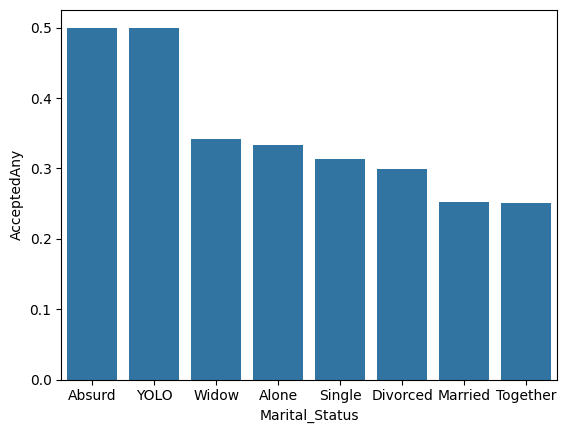

In [223]:
sns.barplot(data=grp2)